In [2417]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from scipy.optimize import curve_fit

import preprocessor as pp

In [2419]:
import importlib
importlib.reload(pp)

<module 'preprocessor' from '/Users/victorli/Desktop/vsc/Programming with Data/DS2500/Battery-RUL-Analysis/preprocessor.py'>

## Preprocessing

In [2422]:
path = 'cleaned_dataset/'

In [2424]:
df = pp.read_clean_file(path)
df

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,2010-07-21 15:00:35.093000,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,2010-07-21 16:53:45.968000,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,2010-07-21 17:25:40.670999,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,2010-07-21 20:31:05.000000,24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,2010-07-21 21:02:56.984000,4,B0047,4,5,00005.csv,1.524366,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,2010-09-30 07:36:45.045999,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,2010-09-30 08:08:36.328000,4,B0055,248,7562,07562.csv,1.020138,NaN,NaN
7562,charge,2010-09-30 08:48:54.250000,4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,2010-09-30 11:50:17.687000,4,B0055,250,7564,07564.csv,0.990759,NaN,NaN


In [2426]:
BATTERIES = sorted(df['battery_id'].value_counts().index.tolist())
#bad_batteries = ['B0038', 'B0039', 'B0040', 'B0041', 'B0052'] #manually found, batteries 38-41 have rising capacities
#while battery 52 only has 4 valid discharge datapoints
#BATTERIES = [b for b in BATTERIES if b not in bad_batteries]
print(len(BATTERIES))
print(BATTERIES)


34
['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']


In [2428]:
print(dis_tr.dtypes)

start_time                        datetime64[ns]
ambient_temperature                        int64
battery_id                                object
uid                                        int64
filename                                  object
Capacity                                 float64
cycle_number                               int64
SOH                                      float64
EOL_cycle                                  int64
RUL                                        int64
mean_voltage                             float64
max_voltage                              float64
min_voltage                              float64
mean_current                             float64
max_current                              float64
mean_temperature                         float64
max_temperature                          float64
discharge_time                           float64
r_internal                               float64
mean_dvdt                                float64
capacity_Ah         

In [2430]:
#helper functions to plot predictions vs actual

def plot_capacity_for_battery(df, battery_id):
    d = df[df["battery_id"] == battery_id]
    
    if d.empty:
        print(f"No data for battery_id {battery_id}")
        return

    plt.figure(figsize=(12,5))

    x = np.arange(len(d))

    plt.plot(x, d["Capacity"], label="True Capacity", linewidth=3)
    plt.plot(x, d["pred_knn_cap"], label="KNN Prediction", linestyle="--")
    plt.plot(x, d["pred_lin_cap"], label="Linear Reg Prediction", linestyle=":")
    plt.plot(x, d["pred_rf_cap"], label="RF Prediction", linestyle="--")
    plt.plot(x, d["pred_xgb_cap"], label="XGB Prediction", linestyle=":")

    plt.title(f"Capacity Prediction – Battery {battery_id}")
    plt.xlabel("Cycle")
    plt.ylabel("Capacity (Ah)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_rul_for_battery(df, battery_id):
    d = df[df["battery_id"] == battery_id]
    
    if d.empty:
        print(f"No data for battery_id {battery_id}")
        return

    plt.figure(figsize=(12,5))

    x = np.arange(len(d))

    plt.plot(x, d["RUL"], label="True RUL", linewidth=3)
    plt.plot(x, d["pred_knn_rul"], label="KNN Prediction", linestyle="--")
    plt.plot(x, d["pred_lin_rul"], label="Linear Reg Prediction", linestyle=":")
    plt.plot(x, d["pred_rf_rul"], label="RF Prediction", linestyle="--")
    plt.plot(x, d["pred_xgb_rul"], label="XGB Prediction", linestyle=":")

    plt.title(f"RUL Prediction – Battery {battery_id}")
    plt.xlabel("Cycle")
    plt.ylabel("RUL (cycles)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Validation Set:

In [2433]:
#validation dataset defining
bat_tr, bat_val = train_test_split(BATTERIES,test_size=0.2,random_state=21)
print(bat_tr)
print(bat_val)

df_tr = df[df['battery_id'].isin(bat_tr)]
df_val = df[df['battery_id'].isin(bat_val)]
dis_tr = pp.get_discharges_phyiscs(path, df_tr)
dis_val = pp.get_discharges_phyiscs(path, df_val)
dis_tr = pp.merge_impedance_with_discharges(df_tr, dis_tr, path)
dis_val = pp.merge_impedance_with_discharges(df_val, dis_val, path)

['B0055', 'B0026', 'B0042', 'B0045', 'B0028', 'B0050', 'B0032', 'B0041', 'B0027', 'B0053', 'B0044', 'B0051', 'B0056', 'B0033', 'B0036', 'B0029', 'B0031', 'B0040', 'B0007', 'B0018', 'B0054', 'B0052', 'B0039', 'B0025', 'B0047', 'B0038', 'B0030']
['B0006', 'B0043', 'B0049', 'B0005', 'B0034', 'B0048', 'B0046']


### Predicting Capacity

In [2435]:
cap_features = ['ambient_temperature', 
            'cycle_number',
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time']
#these features were derived before any physics equations or theories were applied
target = 'Capacity'
capx_tr_df = dis_tr[cap_features]
disx_tr = dis_tr[cap_features].values
capy_tr = dis_tr[target].values
capx_val = dis_val[cap_features].values
capy_val = dis_val[target].values

In [2438]:
cap_features_physics = ['ambient_temperature', 
            'cycle_number',
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time',
            'r_internal', 
            'mean_dvdt', 
            'voltage_drop',
           'Rectified_impedance_phase_mean',
            'Re', 'Rct']
target = 'Capacity'
capx_tr_df = dis_tr[cap_features_physics]
capx_tr = dis_tr[cap_features_physics].values
capy_tr = dis_tr[target].values
capx_val = dis_val[cap_features_physics].values
capy_val = dis_val[target].values

In [2440]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=21
)
rf_model.fit(capx_tr, capy_tr)

pred_rf = rf_model.predict(capx_val)

print("RF MAE:", mean_absolute_error(capy_val, pred_rf))
print("RF MSE:", mean_squared_error(capy_val, pred_rf))
print("RF R2:", r2_score(capy_val, pred_rf))

rf_capacity_importance = pd.Series(rf_model.feature_importances_, index=capx_tr_df.columns).sort_values(ascending=False)
print(rf_capacity_importance)

dis_val["pred_rf_cap"]  = pred_rf
'''
trained on 'features':
RF MAE: 0.05822644393428646
RF MSE: 0.006476585525975368
RF R2: 0.956912848959123

trained on 'features_physics':
RF MAE: 0.05310113028988328
RF MSE: 0.005400857194406244
RF R2: 0.964069408370772
'''

RF MAE: 0.05310113028988328
RF MSE: 0.005400857194406244
RF R2: 0.964069408370772
discharge_time                    0.316096
Rct                               0.212350
ambient_temperature               0.205806
voltage_drop                      0.102732
mean_temperature                  0.060533
mean_current                      0.039058
r_internal                        0.019028
cycle_number                      0.013200
Rectified_impedance_phase_mean    0.007085
max_temperature                   0.006717
max_voltage                       0.004419
Re                                0.003684
min_voltage                       0.003644
mean_voltage                      0.003504
mean_dvdt                         0.001760
max_current                       0.000383
dtype: float64


"\ntrained on 'features':\nRF MAE: 0.05822644393428646\nRF MSE: 0.006476585525975368\nRF R2: 0.956912848959123\n\ntrained on 'features_physics':\nRF MAE: 0.05310113028988328\nRF MSE: 0.005400857194406244\nRF R2: 0.964069408370772\n"

In [2442]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=21
)

xgb_model.fit(capx_tr, capy_tr)

pred_xgb = xgb_model.predict(capx_val)

print("XGB MAE:", mean_absolute_error(capy_val, pred_xgb))
print("XGB RMSE:", np.sqrt(mean_squared_error(capy_val, pred_xgb)))
print("XGB R2:", r2_score(capy_val, pred_xgb))

xgb_capacity_importance = pd.Series(xgb_model.feature_importances_, index=capx_tr_df.columns).sort_values(ascending=False)
print(xgb_capacity_importance)

dis_val["pred_xgb_cap"]  = pred_xgb
'''
trained on 'features':
XGB MAE: 0.0684863136039123
XGB RMSE: 0.09520086785419211
XGB R2: 0.939704696011131

trained on 'features_physics':
XGB MAE: 0.04702314655641365
XGB RMSE: 0.06297932900469197
XGB R2: 0.973612531207207
'''

XGB MAE: 0.04702314655641365
XGB RMSE: 0.06297932900469197
XGB R2: 0.973612531207207
ambient_temperature               0.519356
Rct                               0.185201
discharge_time                    0.104673
voltage_drop                      0.050938
r_internal                        0.046603
mean_temperature                  0.036942
mean_current                      0.016538
mean_dvdt                         0.009818
Rectified_impedance_phase_mean    0.009677
max_temperature                   0.006245
Re                                0.004005
cycle_number                      0.003610
max_voltage                       0.002293
min_voltage                       0.002148
mean_voltage                      0.001826
max_current                       0.000126
dtype: float32


"\ntrained on 'features':\nXGB MAE: 0.0684863136039123\nXGB RMSE: 0.09520086785419211\nXGB R2: 0.939704696011131\n\ntrained on 'features_physics':\nXGB MAE: 0.04702314655641365\nXGB RMSE: 0.06297932900469197\nXGB R2: 0.973612531207207\n"

In [2444]:
knn_model = KNeighborsRegressor(n_neighbors=3) 

knn_model.fit(capx_tr, capy_tr)

pred_knn = knn_model.predict(capx_val)

print("KNN MAE:", mean_absolute_error(capy_val, pred_knn))
print("KNN RMSE:", np.sqrt(mean_squared_error(capy_val, pred_knn)))
print("KNN R2:", r2_score(capy_val, pred_knn))

dis_val["pred_knn_cap"]  = pred_knn

'''
features:
KNN MAE: 0.12521962351261995
KNN RMSE: 0.16891078672714072
KNN R2: 0.8101911562487086

features_physics:
KNN MAE: 0.12346724118941341
KNN RMSE: 0.16752727304293738
KNN R2: 0.8132877929232842
'''

KNN MAE: 0.12346724118941341
KNN RMSE: 0.16752727304293738
KNN R2: 0.8132877929232842


'\nfeatures:\nKNN MAE: 0.12521962351261995\nKNN RMSE: 0.16891078672714072\nKNN R2: 0.8101911562487086\n\nfeatures_physics:\nKNN MAE: 0.12346724118941341\nKNN RMSE: 0.16752727304293738\nKNN R2: 0.8132877929232842\n'

In [2446]:
lin_model = LinearRegression()
lin_model.fit(capx_tr, capy_tr)

pred_lin = lin_model.predict(capx_val)

print("LIN MAE:", mean_absolute_error(capy_val, pred_lin))
print("LIN RMSE:", np.sqrt(mean_squared_error(capy_val, pred_lin)))
print("LIN R2:", r2_score(capy_val, pred_lin))

dis_val["pred_lin_cap"]  = pred_lin

coef = lin_model.coef_
lin_cap_importance = pd.Series(coef, index=capx_tr_df.columns).abs().sort_values(ascending=False)
print(lin_cap_importance)
'''
features:
LIN MAE: 0.1431090778914432
LIN RMSE: 0.1854115335409672
LIN R2: 0.771295259737238

features_physics:
LIN MAE: 0.1036518653516941
LIN RMSE: 0.1464665381057981
LIN R2: 0.8572820800248101
'''

LIN MAE: 0.1036518653516941
LIN RMSE: 0.1464665381057981
LIN R2: 0.8572820800248101
mean_dvdt                         49.307875
Rectified_impedance_phase_mean    14.348154
max_current                       12.630219
r_internal                         5.321946
Rct                                2.401930
Re                                 0.897965
mean_voltage                       0.706987
mean_current                       0.399717
min_voltage                        0.232112
max_voltage                        0.098090
mean_temperature                   0.046705
max_temperature                    0.022067
voltage_drop                       0.013935
ambient_temperature                0.008411
discharge_time                     0.000232
cycle_number                       0.000034
dtype: float64


'\nfeatures:\nLIN MAE: 0.1431090778914432\nLIN RMSE: 0.1854115335409672\nLIN R2: 0.771295259737238\n\nfeatures_physics:\nLIN MAE: 0.1036518653516941\nLIN RMSE: 0.1464665381057981\nLIN R2: 0.8572820800248101\n'

In [2494]:
0.8572820800248101-0.771295259737238

0.0859868202875721

['B0006', 'B0043', 'B0049', 'B0005', 'B0034', 'B0048', 'B0046']


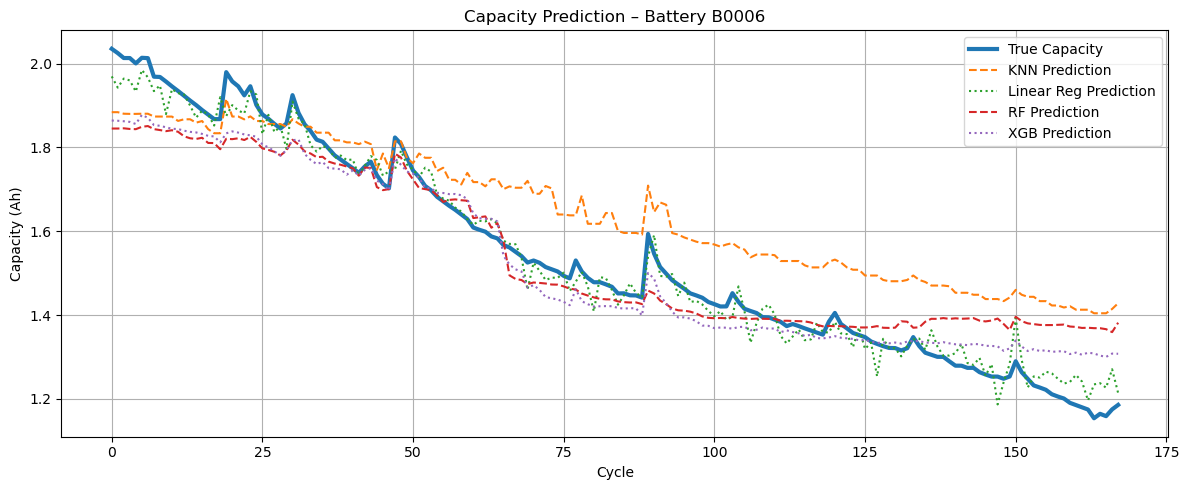

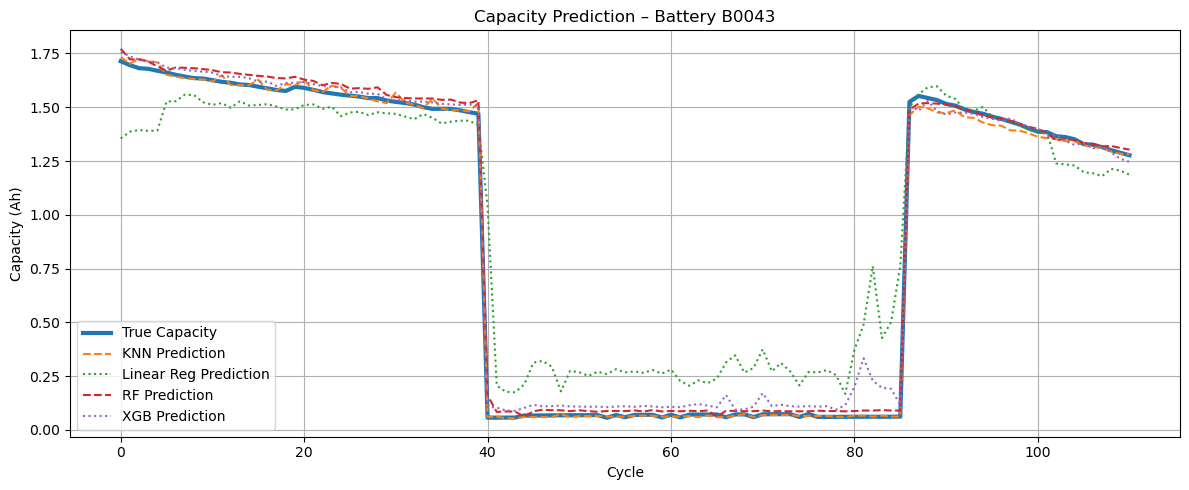

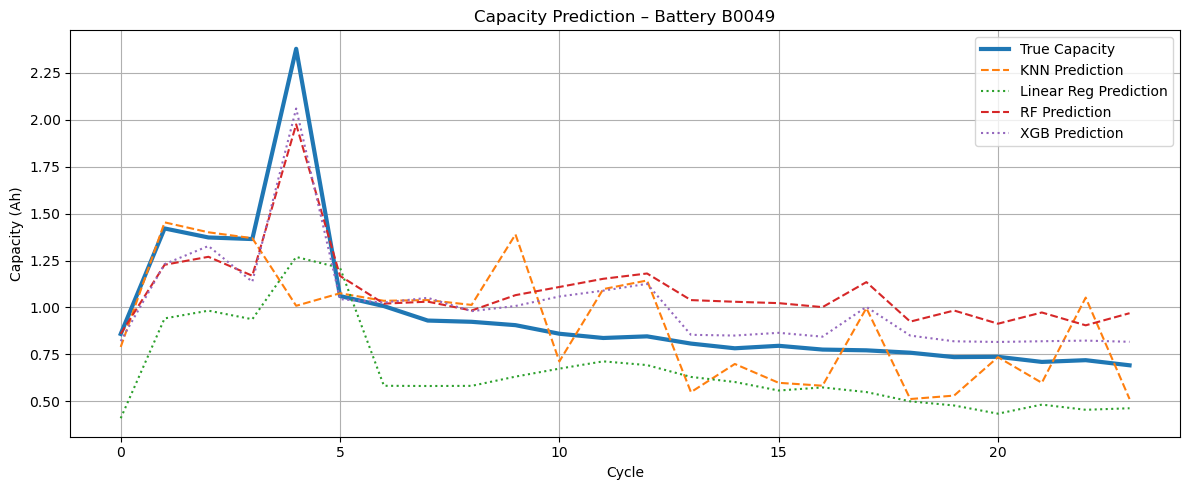

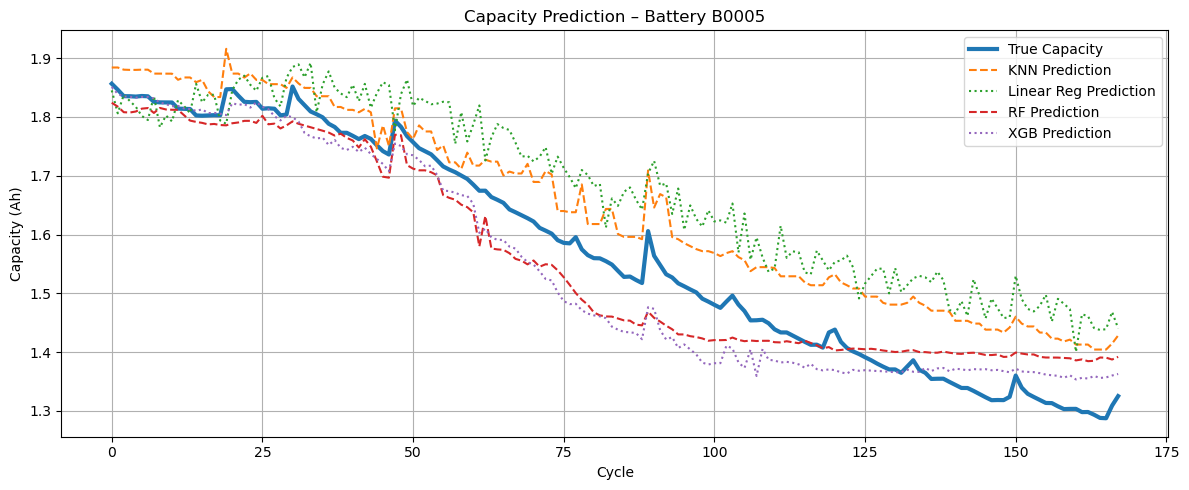

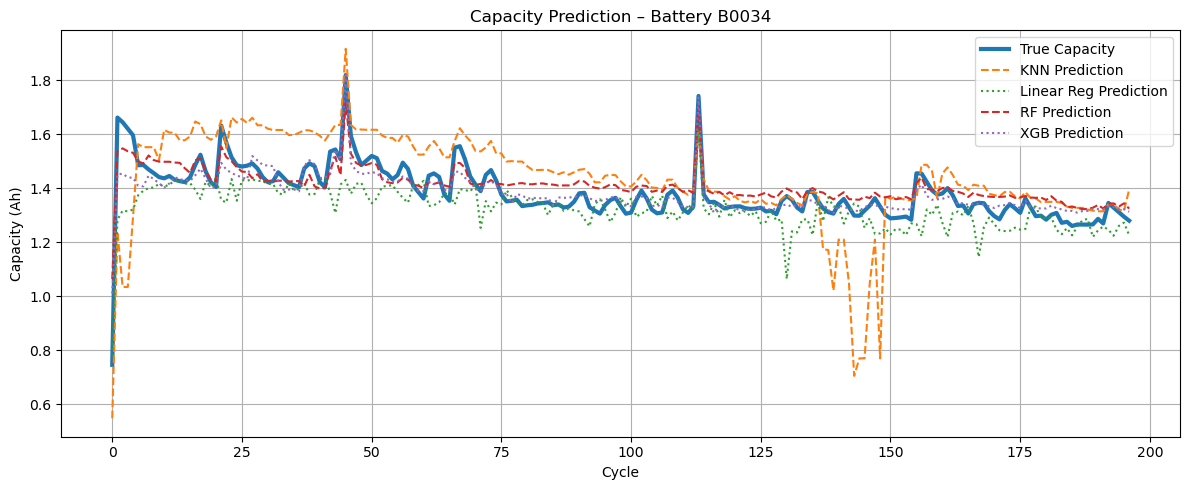

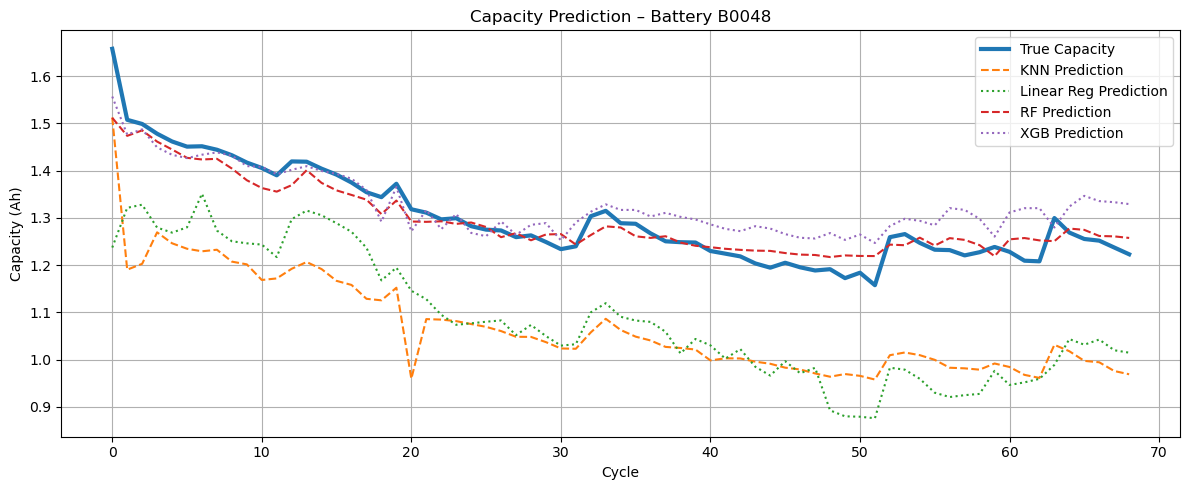

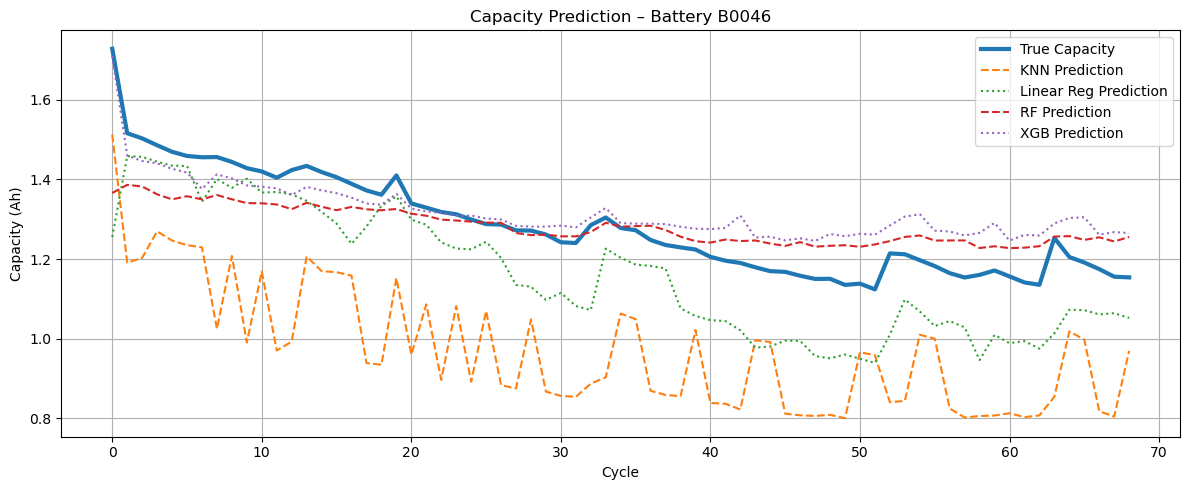

In [2448]:
print(bat_val)
for bat in bat_val:
    plot_capacity_for_battery(dis_val, bat)

### Predicting RUL

In [2451]:
features = ['ambient_temperature', 
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time',
            'r_internal', 
            'mean_dvdt', 
            'voltage_drop',
            'Battery_impedance_real_mean',
            'Battery_impedance_mag_mean',
            'Rectified_impedance_real_mean',
           'Rectified_impedance_phase_mean']

#had to remove cycle number because RUL depends too heavily on it, leaking answers: KNN got .9999 R2 score
target = 'RUL'
rulx_tr_df = dis_tr[features]
rulx_tr = dis_tr[features].values
ruly_tr = dis_tr[target].values
rulx_val = dis_val[features].values
ruly_val = dis_val[target].values

In [2453]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=21
)
rf_model.fit(rulx_tr, ruly_tr)

rul_pred_rf = rf_model.predict(rulx_val)

print("RF MAE:", mean_absolute_error(ruly_val, rul_pred_rf))
print("RF MSE:", mean_squared_error(ruly_val, rul_pred_rf))
print("RF R2:", r2_score(ruly_val, rul_pred_rf))

rf_rul_importance = pd.Series(rf_model.feature_importances_, index=rulx_tr_df.columns).sort_values(ascending=False)
print(rf_rul_importance)

dis_val["pred_rf_rul"]  = rul_pred_rf

'''
RF MAE: 18.088506458468014
RF MSE: 563.3600476477965
RF R2: 0.7813468620128934
'''

RF MAE: 18.088506458468014
RF MSE: 563.3600476477965
RF R2: 0.7813468620128934
discharge_time                    0.579806
mean_current                      0.137147
Rectified_impedance_phase_mean    0.054122
Battery_impedance_real_mean       0.045450
Rectified_impedance_real_mean     0.038539
mean_temperature                  0.034719
Battery_impedance_mag_mean        0.025204
ambient_temperature               0.019472
mean_voltage                      0.015408
max_voltage                       0.012587
mean_dvdt                         0.009270
max_temperature                   0.009033
voltage_drop                      0.007715
r_internal                        0.005565
min_voltage                       0.003457
max_current                       0.002505
dtype: float64


'\nRF MAE: 18.088506458468014\nRF MSE: 563.3600476477965\nRF R2: 0.7813468620128934\n'

In [2455]:

xgb_model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.7,
    colsample_bytree=0.8,
)

xgb_model.fit(rulx_tr, ruly_tr)
rul_pred_xgb = xgb_model.predict(rulx_val)
print("XGB MAE:", mean_absolute_error(ruly_val, rul_pred_xgb))
print("XGB MSE:", mean_squared_error(ruly_val, rul_pred_xgb))
print("XGB R2:", r2_score(ruly_val, rul_pred_xgb))

xgb_rul_importance = pd.Series(xgb_model.feature_importances_, index=rulx_tr_df.columns).sort_values(ascending=False)
print(xgb_rul_importance)

dis_val["pred_xgb_rul"]  = rul_pred_xgb

'''
XGB MAE: 16.18669444071152
XGB MSE: 435.07001430731583
XGB R2: 0.8311392079193671
'''

XGB MAE: 16.18669444071152
XGB MSE: 435.07001430731583
XGB R2: 0.8311392079193671
discharge_time                    0.372882
ambient_temperature               0.139252
mean_current                      0.129431
Rectified_impedance_real_mean     0.091117
Battery_impedance_mag_mean        0.059572
Battery_impedance_real_mean       0.050551
Rectified_impedance_phase_mean    0.045926
mean_temperature                  0.029155
mean_dvdt                         0.026559
max_temperature                   0.012043
voltage_drop                      0.011594
mean_voltage                      0.011150
r_internal                        0.007537
max_voltage                       0.006558
min_voltage                       0.004390
max_current                       0.002284
dtype: float32


'\nXGB MAE: 16.18669444071152\nXGB MSE: 435.07001430731583\nXGB R2: 0.8311392079193671\n'

In [2457]:
knn_model = KNeighborsRegressor(n_neighbors=2) 

knn_model.fit(rulx_tr, ruly_tr)

rul_pred_knn = knn_model.predict(rulx_val)

print("KNN MAE:", mean_absolute_error(ruly_val, rul_pred_knn))
print("KNN MSE:", mean_squared_error(ruly_val, rul_pred_knn))
print("KNN R2:", r2_score(ruly_val, rul_pred_knn))

dis_val["pred_knn_rul"]  = rul_pred_knn

'''
KNN MAE: 4.46712158808933
KNN MSE: 69.03070719602978
KNN R2: 0.9732075769147949
'''

KNN MAE: 4.46712158808933
KNN MSE: 69.03070719602978
KNN R2: 0.9732075769147949


'\nKNN MAE: 4.46712158808933\nKNN MSE: 69.03070719602978\nKNN R2: 0.9732075769147949\n'

In [2459]:
lin_model = LinearRegression()
lin_model.fit(rulx_tr, ruly_tr)

rul_pred_lin = lin_model.predict(rulx_val)

print("LIN MAE:", mean_absolute_error(ruly_val, rul_pred_lin))
print("LIN RMSE:", np.sqrt(mean_squared_error(ruly_val, rul_pred_lin)))
print("LIN R2:", r2_score(ruly_val, rul_pred_lin))

dis_val["pred_lin_rul"]  = rul_pred_lin

'''
LIN MAE: 34.38379980479389
LIN RMSE: 42.72302735588455
LIN R2: 0.2915752778721967
'''

LIN MAE: 34.38379980479389
LIN RMSE: 42.72302735588455
LIN R2: 0.2915752778721967


'\nLIN MAE: 34.38379980479389\nLIN RMSE: 42.72302735588455\nLIN R2: 0.2915752778721967\n'

['B0006', 'B0043', 'B0049', 'B0005', 'B0034', 'B0048', 'B0046']


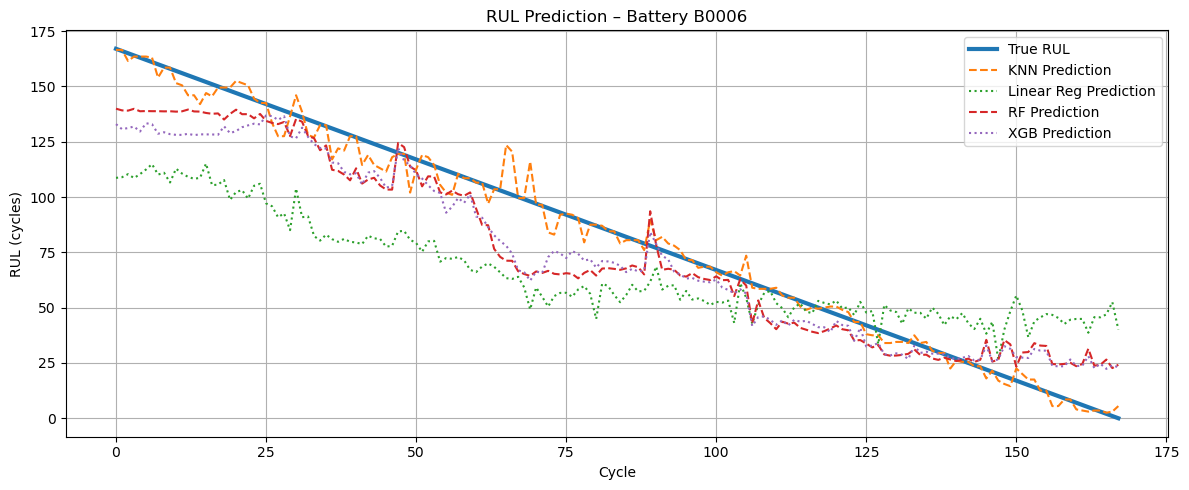

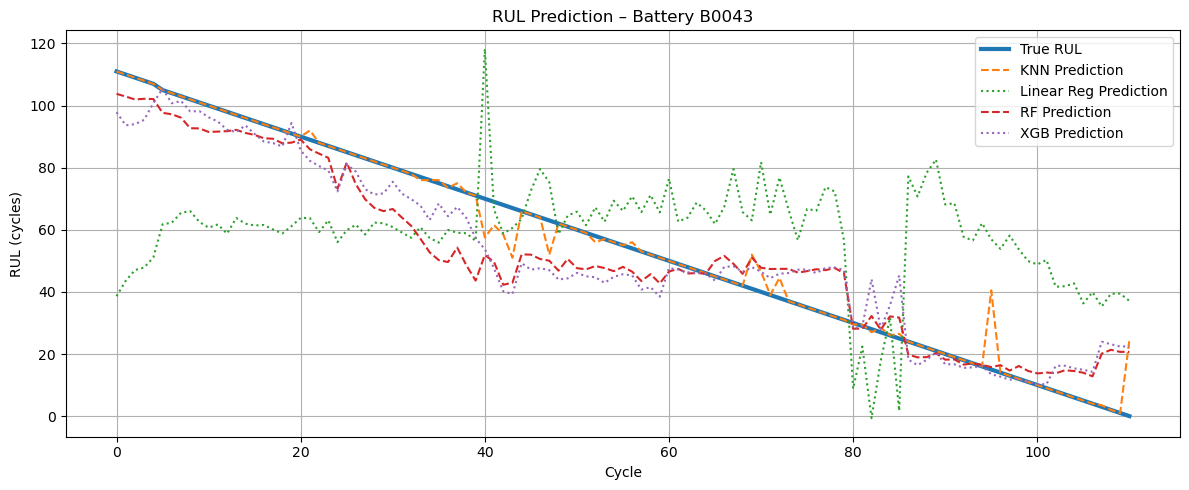

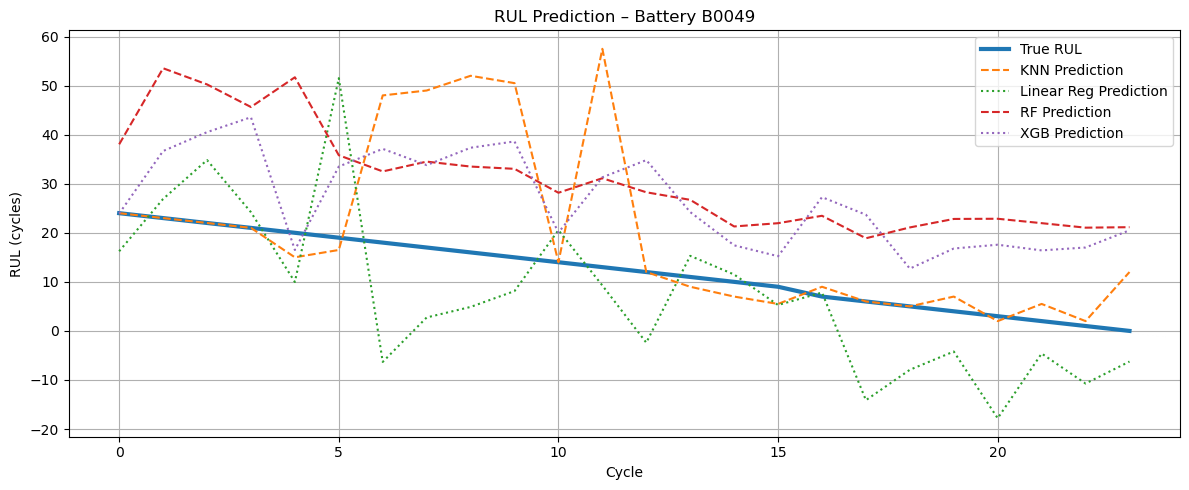

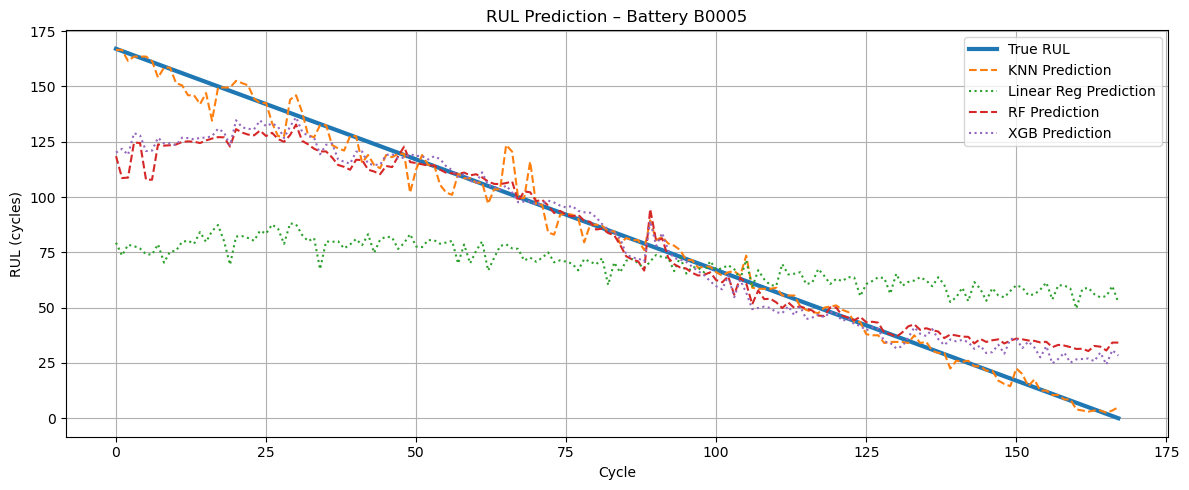

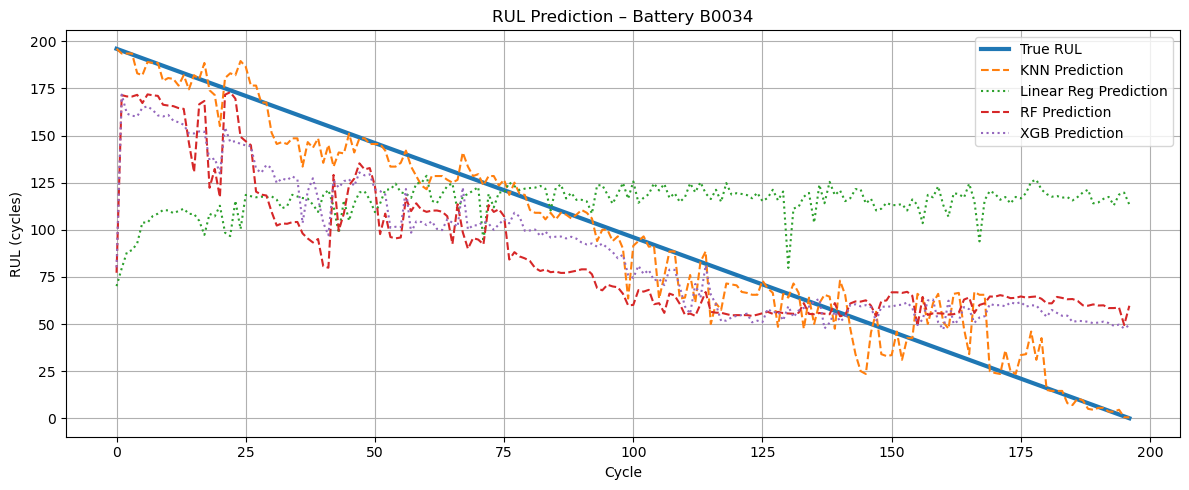

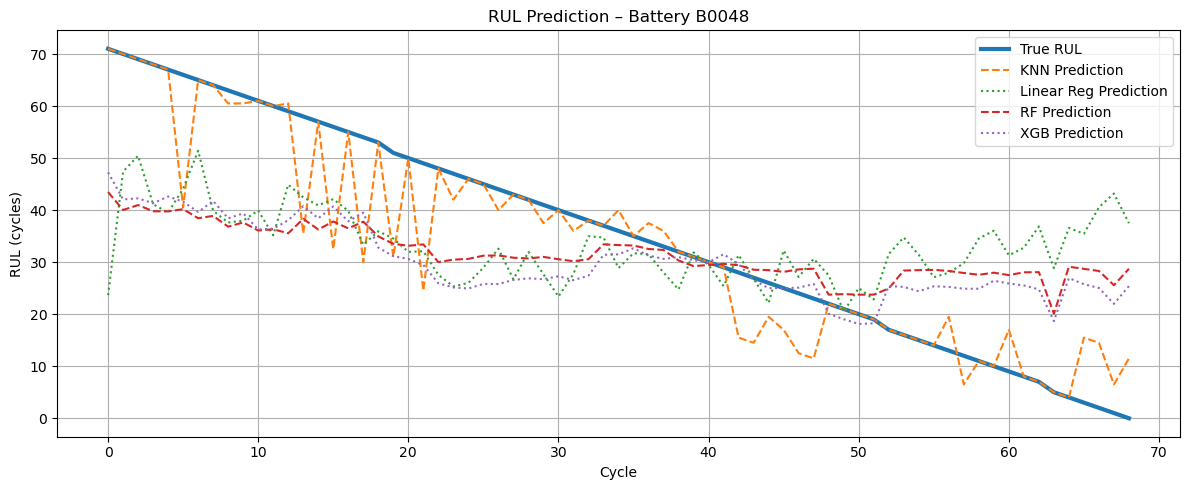

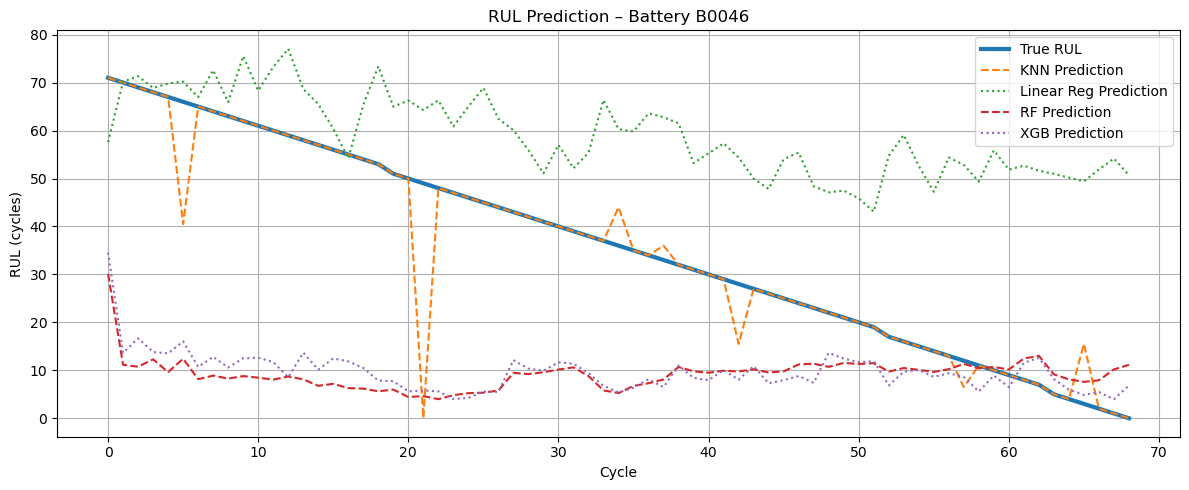

In [2461]:
print(bat_val)
for bat in bat_val:
    plot_rul_for_battery(dis_val, bat)

## Test Set:

### Capacity

In [2465]:
bat_tr, bat_te = train_test_split(BATTERIES, test_size=0.24, random_state=21)
print(bat_tr)
print(bat_te)

df_tr = df[df['battery_id'].isin(bat_tr)]
df_te = df[df['battery_id'].isin(bat_te)]
dis_tr = pp.get_discharges_phyiscs(path, df_tr)
dis_te = pp.get_discharges_phyiscs(path, df_te)
dis_tr = pp.merge_impedance_with_discharges(df_tr, dis_tr, path)
dis_te = pp.merge_impedance_with_discharges(df_te, dis_te, path)

['B0042', 'B0045', 'B0028', 'B0050', 'B0032', 'B0041', 'B0027', 'B0053', 'B0044', 'B0051', 'B0056', 'B0033', 'B0036', 'B0029', 'B0031', 'B0040', 'B0007', 'B0018', 'B0054', 'B0052', 'B0039', 'B0025', 'B0047', 'B0038', 'B0030']
['B0006', 'B0043', 'B0049', 'B0005', 'B0034', 'B0048', 'B0046', 'B0055', 'B0026']


In [2466]:
cap_features = ['ambient_temperature', 
            'cycle_number',
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time',
            'r_internal', 
            'mean_dvdt', 
            'voltage_drop',
           'Rectified_impedance_phase_mean',
            'Re', 'Rct']
target = 'Capacity'

capx_tr_df = dis_tr[rul_features]
capx_tr = dis_tr[cap_features].values
capy_tr = dis_tr[target].values
capx_te = dis_te[cap_features].values
capy_te = dis_te[target].values

In [2467]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=21
)
rf_model.fit(capx_tr, capy_tr)

pred_rf = rf_model.predict(capx_te)

print("RF MAE:", mean_absolute_error(capy_te, pred_rf))
print("RF MSE:", mean_squared_error(capy_te, pred_rf))
print("RF R2:", r2_score(capy_te, pred_rf))
rf_capacity_importance = pd.Series(rf_model.feature_importances_, index=capx_tr_df.columns).sort_values(ascending=False)
print(rf_capacity_importance)

dis_te["pred_rf_cap"]  = pred_rf

RF MAE: 0.0835321074010873
RF MSE: 0.015693643909084325
RF R2: 0.8911788243075685
Rectified_impedance_phase_mean    0.398960
r_internal                        0.390537
Battery_impedance_real_mean       0.084371
max_current                       0.046634
max_temperature                   0.021255
mean_voltage                      0.013236
Battery_impedance_mag_mean        0.011075
ambient_temperature               0.006399
min_voltage                       0.006189
discharge_time                    0.005513
Rectified_impedance_real_mean     0.004417
mean_current                      0.003841
max_voltage                       0.002984
mean_dvdt                         0.002352
voltage_drop                      0.001685
mean_temperature                  0.000553
dtype: float64


In [2468]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=21
)

xgb_model.fit(capx_tr, capy_tr)

pred_xgb = xgb_model.predict(capx_te)

print("XGB MAE:", mean_absolute_error(capy_te, pred_xgb))
print("XGB RMSE:", np.sqrt(mean_squared_error(capy_te, pred_xgb)))
print("XGB R2:", r2_score(capy_te, pred_xgb))
xgb_capacity_importance = pd.Series(xgb_model.feature_importances_, index=capx_tr_df.columns).sort_values(ascending=False)
print(xgb_capacity_importance)

dis_te["pred_xgb_cap"]  = pred_xgb

XGB MAE: 0.0650359846009438
XGB RMSE: 0.0919778939507782
XGB R2: 0.9413380437316218
Rectified_impedance_phase_mean    0.429995
r_internal                        0.205266
ambient_temperature               0.076010
mean_dvdt                         0.067441
Battery_impedance_real_mean       0.063561
max_temperature                   0.048930
max_current                       0.033524
voltage_drop                      0.019312
Battery_impedance_mag_mean        0.016947
discharge_time                    0.016408
Rectified_impedance_real_mean     0.008416
mean_voltage                      0.005327
min_voltage                       0.004347
mean_current                      0.002143
max_voltage                       0.002087
mean_temperature                  0.000286
dtype: float32


In [2469]:
knn_model = KNeighborsRegressor(n_neighbors=3) 

knn_model.fit(capx_tr, capy_tr)

pred_knn = knn_model.predict(capx_te)

print("KNN MAE:", mean_absolute_error(capy_te, pred_knn))
print("KNN RMSE:", np.sqrt(mean_squared_error(capy_te, pred_knn)))
print("KNN R2:", r2_score(capy_te, pred_knn))

dis_te["pred_knn_cap"]  = pred_knn

KNN MAE: 0.112262173999136
KNN RMSE: 0.15705791083000847
KNN R2: 0.8289554456269296


In [2472]:
lin_model = LinearRegression()
lin_model.fit(capx_tr, capy_tr)

pred_lin = lin_model.predict(capx_te)

print("LIN MAE:", mean_absolute_error(capy_te, pred_lin))
print("LIN RMSE:", np.sqrt(mean_squared_error(capy_te, pred_lin)))
print("LIN R2:", r2_score(capy_te, pred_lin))

coef = lin_model.coef_
lin_cap_importance = pd.Series(coef, index=capx_tr_df.columns).abs().sort_values(ascending=False)
print(lin_cap_importance)

dis_te["pred_lin_cap"]  = pred_lin

LIN MAE: 0.12019266873002707
LIN RMSE: 0.16626113547638058
LIN R2: 0.8083225143501216
voltage_drop                      46.663974
Battery_impedance_mag_mean        17.345084
mean_temperature                  11.652280
mean_dvdt                          7.194800
Rectified_impedance_phase_mean     2.212470
Rectified_impedance_real_mean      0.827396
max_voltage                        0.813132
max_current                        0.445361
mean_current                       0.227461
max_temperature                    0.048770
discharge_time                     0.022570
Battery_impedance_real_mean        0.012596
ambient_temperature                0.005011
r_internal                         0.000236
min_voltage                        0.000225
mean_voltage                       0.000068
dtype: float64


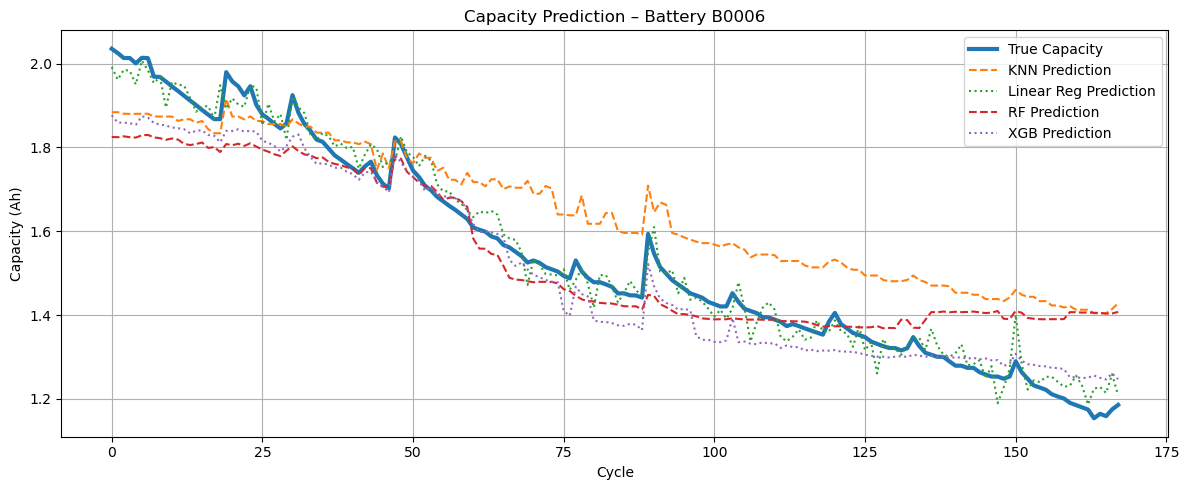

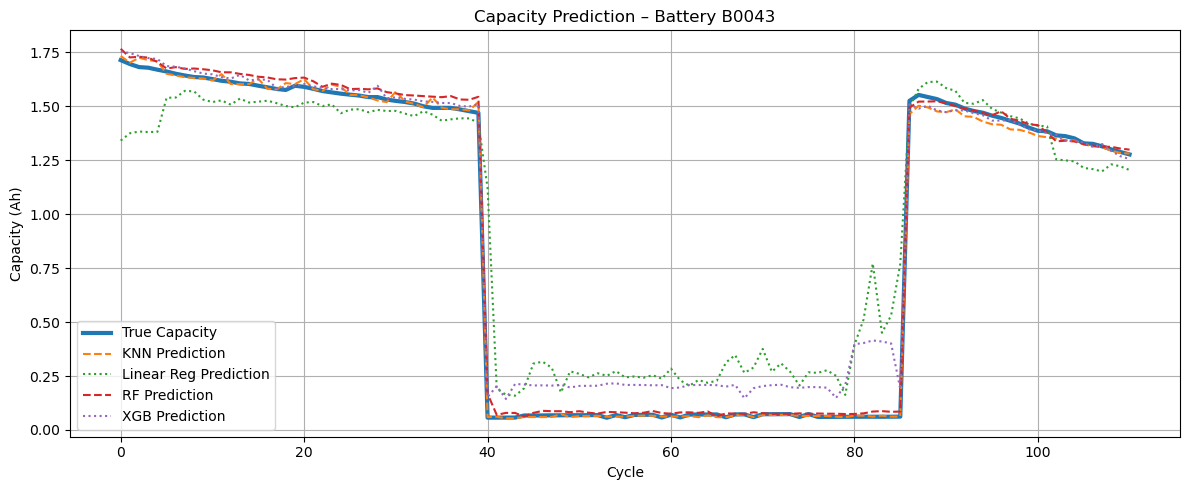

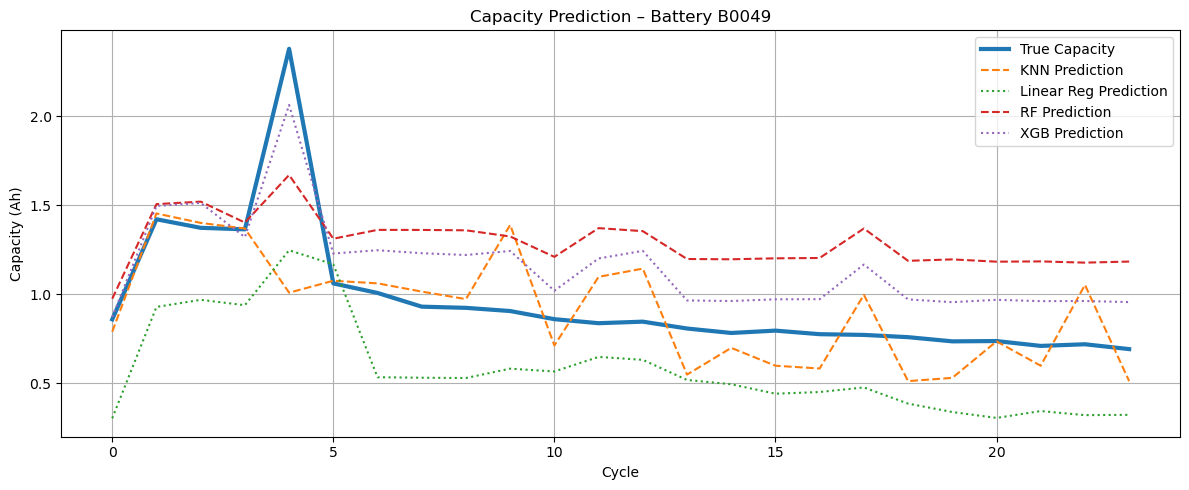

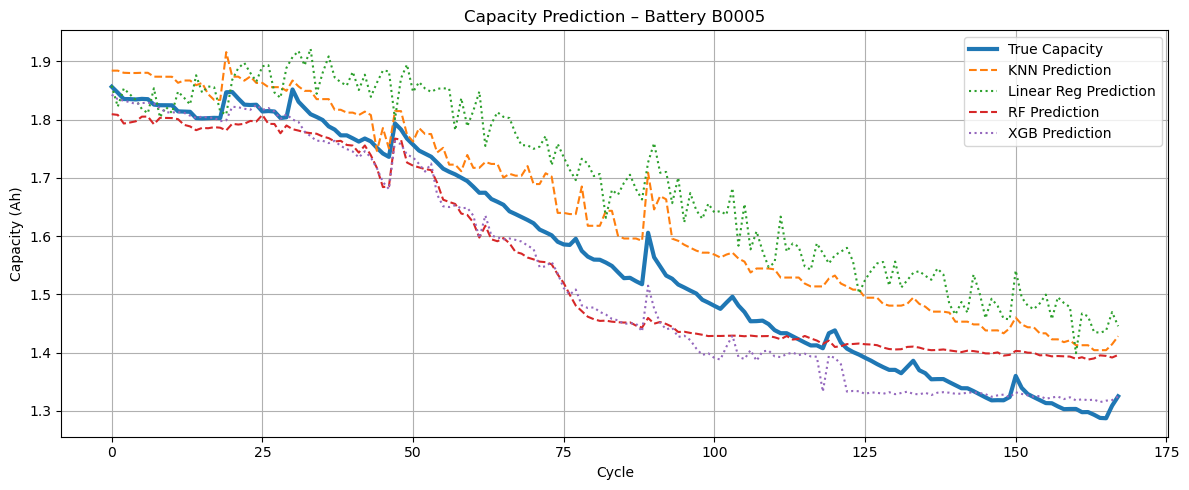

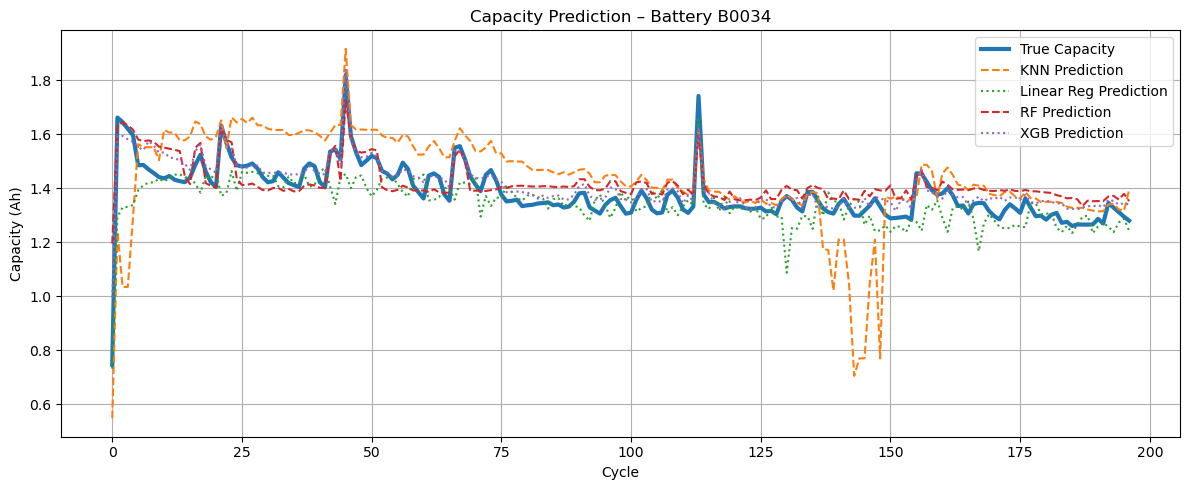

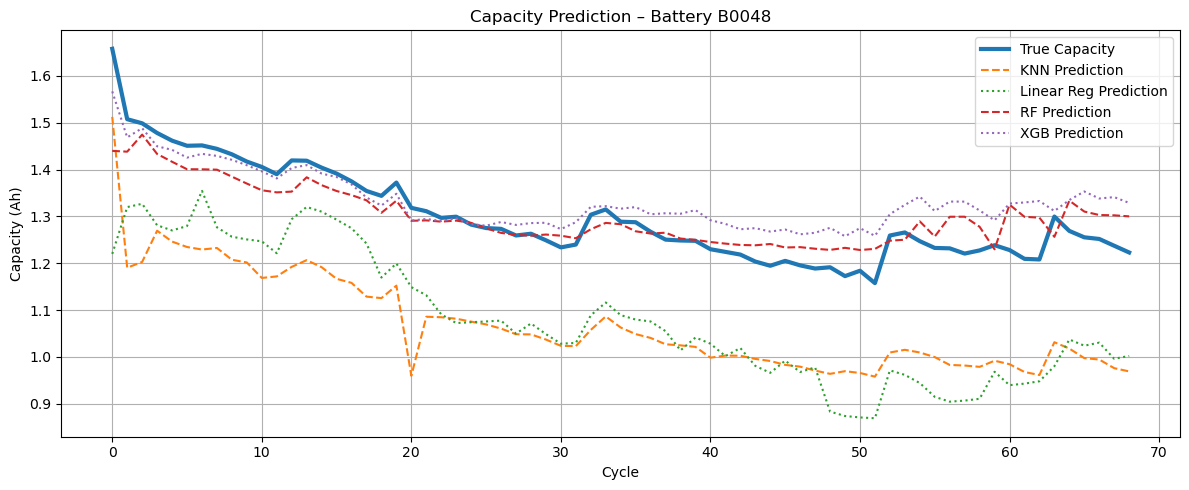

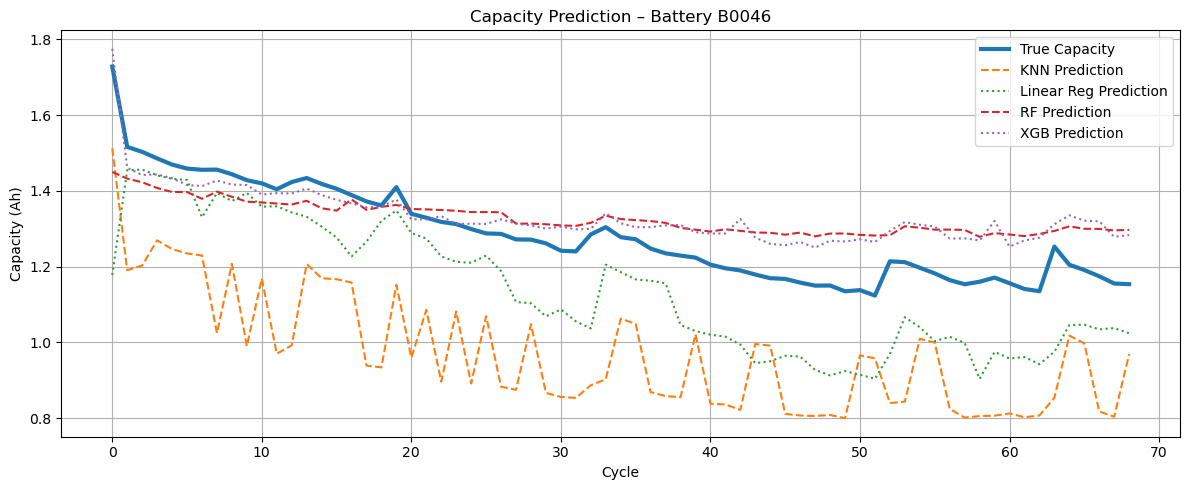

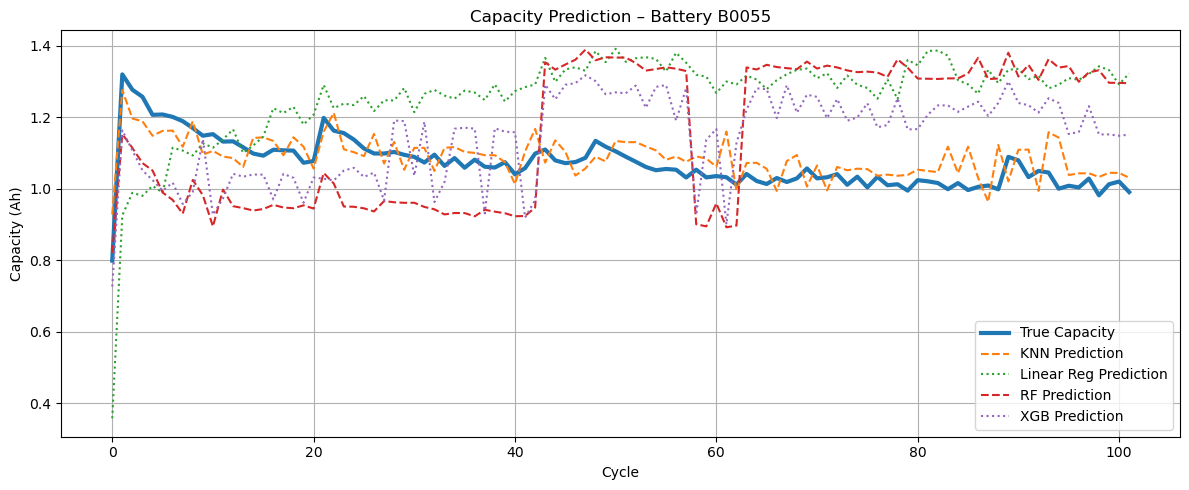

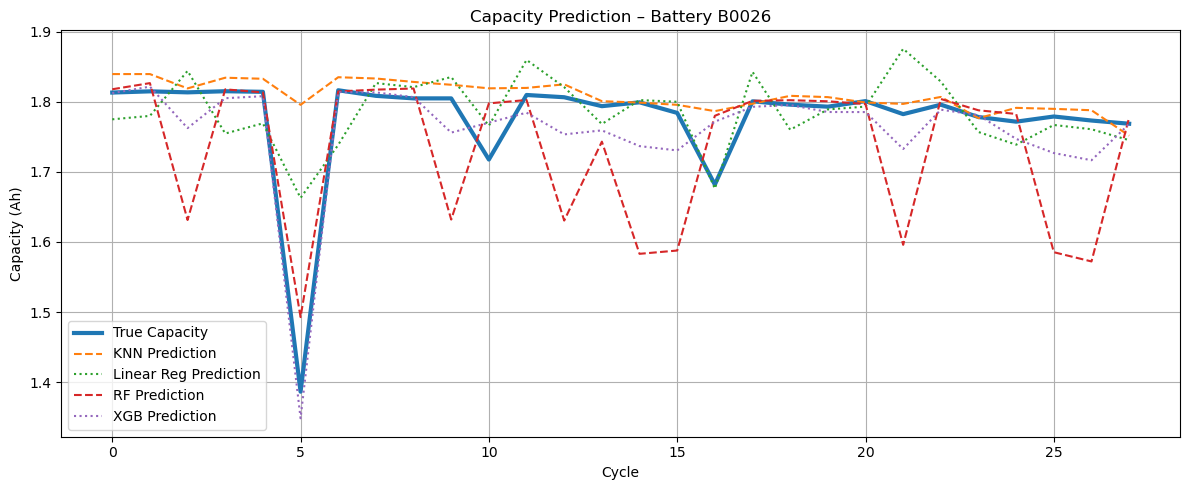

In [2473]:
for bat in bat_te:
    plot_capacity_for_battery(dis_te, bat)

### RUL

In [2476]:
rul_features = ['ambient_temperature', 
            'mean_voltage',
            'max_voltage',
            'min_voltage',
            'mean_current',
            'max_current',
            'mean_temperature',
            'max_temperature',
            'discharge_time',
            'r_internal', 
            'mean_dvdt', 
            'voltage_drop',
            'Battery_impedance_real_mean',
            'Battery_impedance_mag_mean',
            'Rectified_impedance_real_mean',
           'Rectified_impedance_phase_mean']
target = 'RUL'
#had to remove cycle number because RUL depends too heavily on it, leaking answers: KNN got .9999 R2 score

rulx_tr_df = dis_tr[rul_features]
rulx_tr = dis_tr[rul_features].values
ruly_tr = dis_tr[target].values
rulx_te = dis_te[rul_features].values
ruly_te = dis_te[target].values

In [2480]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=21
)
rf_model.fit(rulx_tr, ruly_tr)

rul_pred_rf = rf_model.predict(rulx_te)

print("RF MAE:", mean_absolute_error(ruly_te, rul_pred_rf))
print("RF MSE:", mean_squared_error(ruly_te, rul_pred_rf))
print("RF R2:", r2_score(ruly_te, rul_pred_rf))

rf_rul_importance = pd.Series(rf_model.feature_importances_, index=rulx_tr_df.columns).sort_values(ascending=False)
print(rf_rul_importance)


dis_te["pred_rf_rul"]  = rul_pred_rf

RF MAE: 15.727956804520883
RF MSE: 443.9090253977274
RF R2: 0.8193445527429866
discharge_time                    0.613246
mean_current                      0.133948
Rectified_impedance_phase_mean    0.042977
Battery_impedance_real_mean       0.042412
Rectified_impedance_real_mean     0.041012
mean_temperature                  0.025243
Battery_impedance_mag_mean        0.021917
mean_voltage                      0.016834
ambient_temperature               0.015971
max_voltage                       0.012352
max_temperature                   0.009115
mean_dvdt                         0.007707
voltage_drop                      0.006907
r_internal                        0.005410
min_voltage                       0.002575
max_current                       0.002373
dtype: float64


In [2481]:
xgb_model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.7,
    colsample_bytree=0.8,
)

xgb_model.fit(rulx_tr, ruly_tr)
rul_pred_xgb = xgb_model.predict(rulx_te)

print("XGB MAE:", mean_absolute_error(ruly_te, rul_pred_xgb))
print("XGB MSE:", mean_squared_error(ruly_te, rul_pred_xgb))
print("XGB R2:", r2_score(ruly_te, rul_pred_xgb))

xgb_rul_importance = pd.Series(xgb_model.feature_importances_, index=rulx_tr_df.columns).sort_values(ascending=False)
print(xgb_rul_importance)

dis_te["pred_xgb_rul"]  = rul_pred_xgb

XGB MAE: 15.362249177745264
XGB MSE: 419.9361911569717
XGB R2: 0.8291006578095634
discharge_time                    0.335868
mean_current                      0.185544
ambient_temperature               0.115615
Rectified_impedance_real_mean     0.093211
Battery_impedance_real_mean       0.051242
Battery_impedance_mag_mean        0.049754
Rectified_impedance_phase_mean    0.041027
mean_temperature                  0.039345
mean_dvdt                         0.025256
voltage_drop                      0.017016
max_temperature                   0.011172
mean_voltage                      0.011169
r_internal                        0.009629
max_voltage                       0.006423
min_voltage                       0.005052
max_current                       0.002677
dtype: float32


In [2484]:
knn_model = KNeighborsRegressor(n_neighbors=2) 

knn_model.fit(rulx_tr, ruly_tr)

rul_pred_knn = knn_model.predict(rulx_te)

print("KNN MAE:", mean_absolute_error(ruly_te, rul_pred_knn))
print("KNN MSE:", mean_squared_error(ruly_te, rul_pred_knn))
print("KNN R2:", r2_score(ruly_te, rul_pred_knn))

dis_te["pred_knn_rul"]  = rul_pred_knn

KNN MAE: 4.7206196581196584
KNN MSE: 78.39342948717949
KNN R2: 0.9680966160727894


In [2485]:
lin_model = LinearRegression()
lin_model.fit(rulx_tr, ruly_tr)

rul_pred_lin = lin_model.predict(rulx_te)

print("LIN MAE:", mean_absolute_error(ruly_te, rul_pred_lin))
print("LIN RMSE:", np.sqrt(mean_squared_error(ruly_te, rul_pred_lin)))
print("LIN R2:", r2_score(ruly_te, rul_pred_lin))

coef = lin_model.coef_
lin_rul_importance = pd.Series(coef, index=rulx_tr_df.columns).abs().sort_values(ascending=False)
print(lin_rul_importance)

dis_te["pred_lin_rul"]  = rul_pred_lin

LIN MAE: 33.95341070837474
LIN RMSE: 41.96058339324318
LIN R2: 0.2834605241954705
max_current                       2421.858602
Rectified_impedance_phase_mean    1689.105641
mean_dvdt                         1036.358765
r_internal                         741.109791
mean_voltage                       164.165158
Battery_impedance_real_mean        126.438019
Rectified_impedance_real_mean      122.859467
max_voltage                        111.090180
mean_current                        27.930430
min_voltage                         21.571940
mean_temperature                     9.323058
max_temperature                      7.584061
voltage_drop                         5.849638
Battery_impedance_mag_mean           2.746729
ambient_temperature                  1.900883
discharge_time                       0.005697
dtype: float64


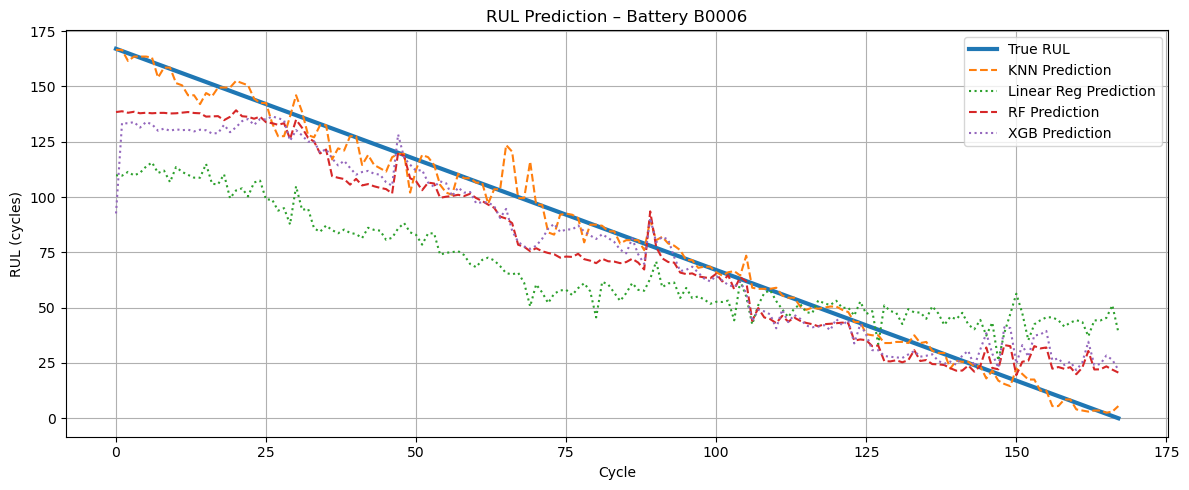

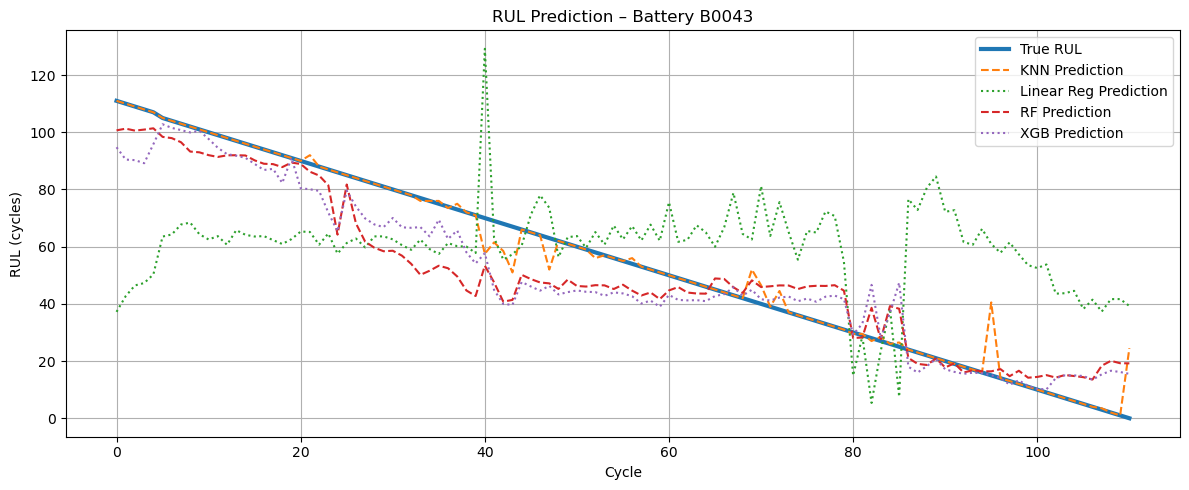

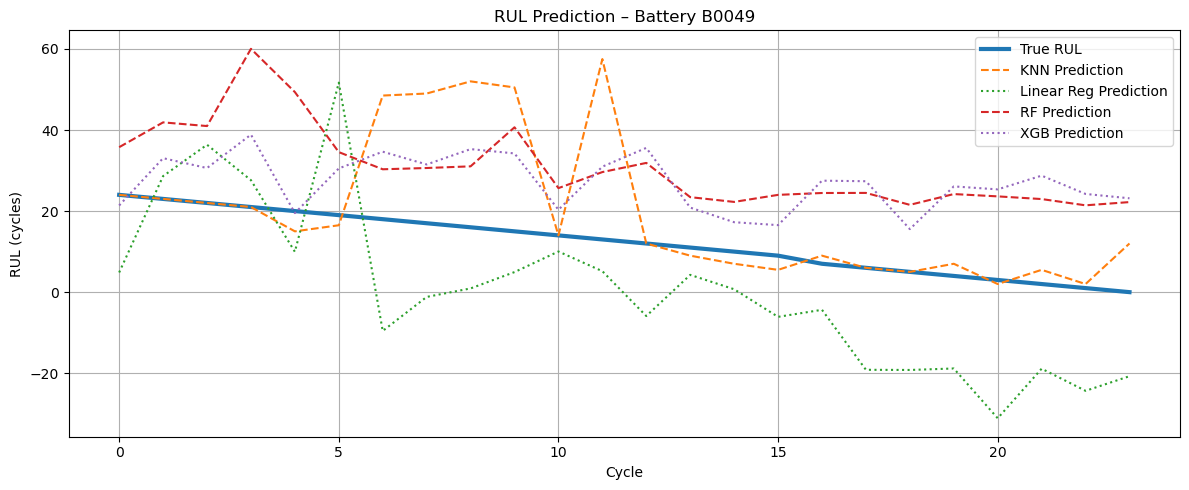

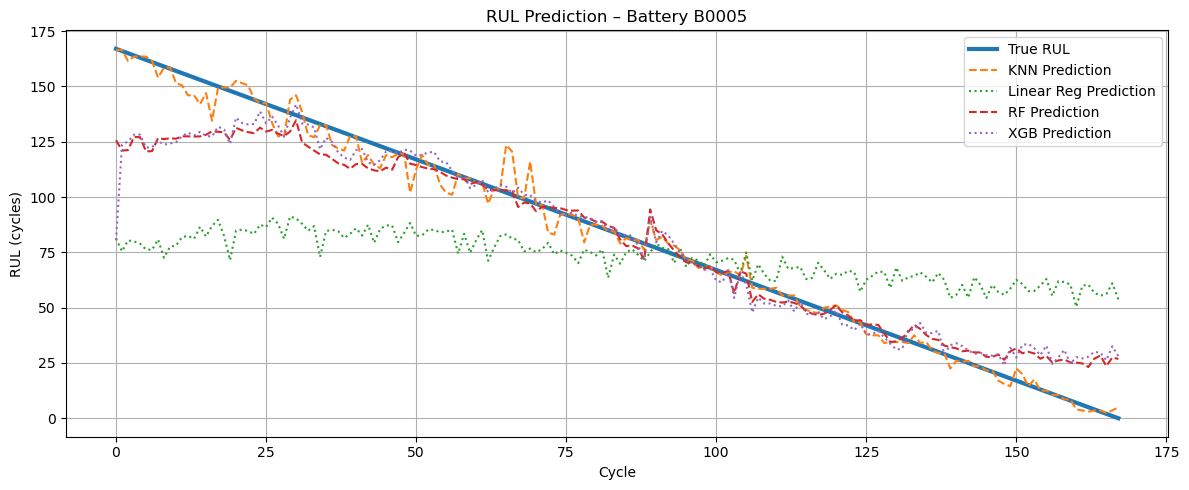

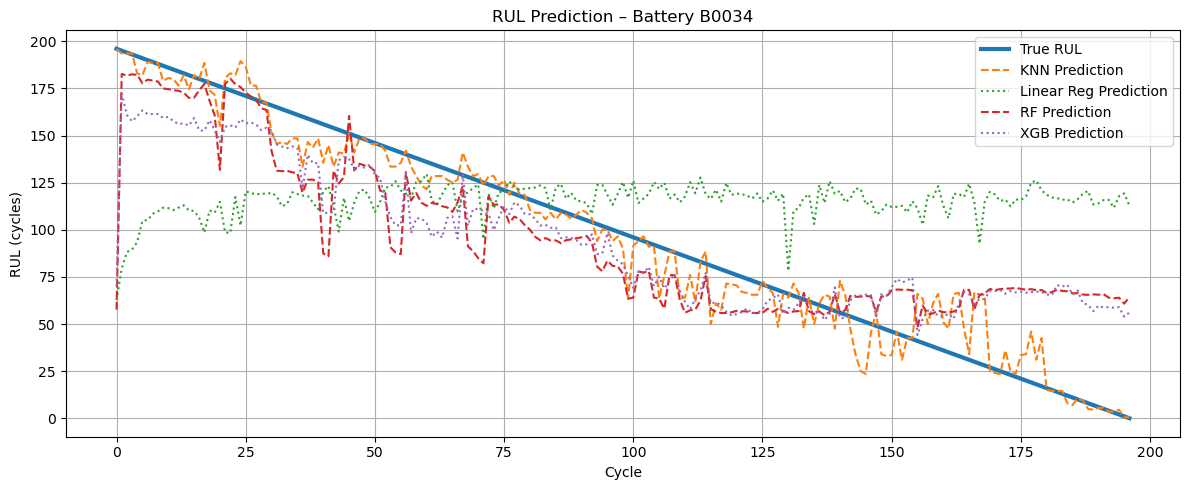

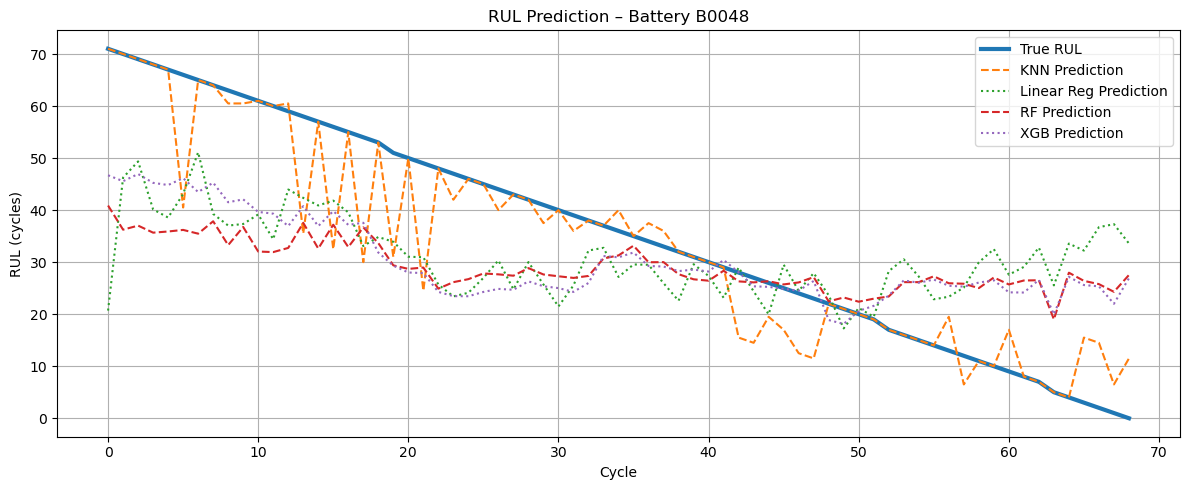

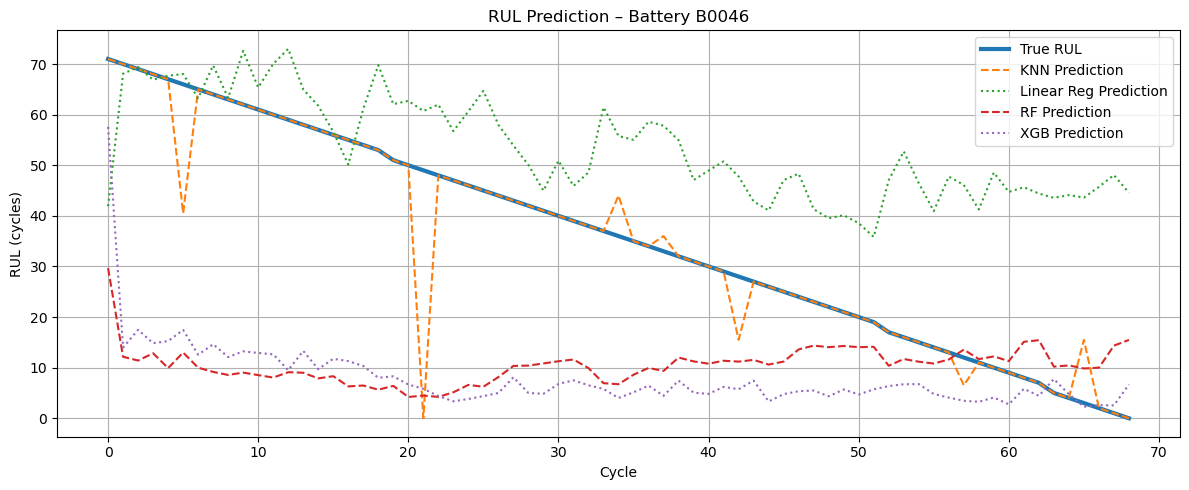

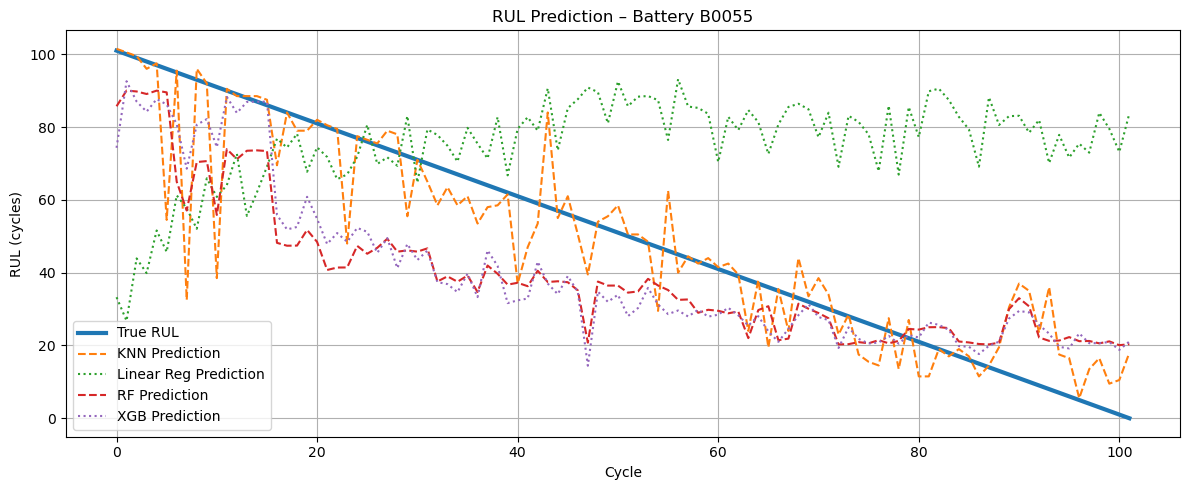

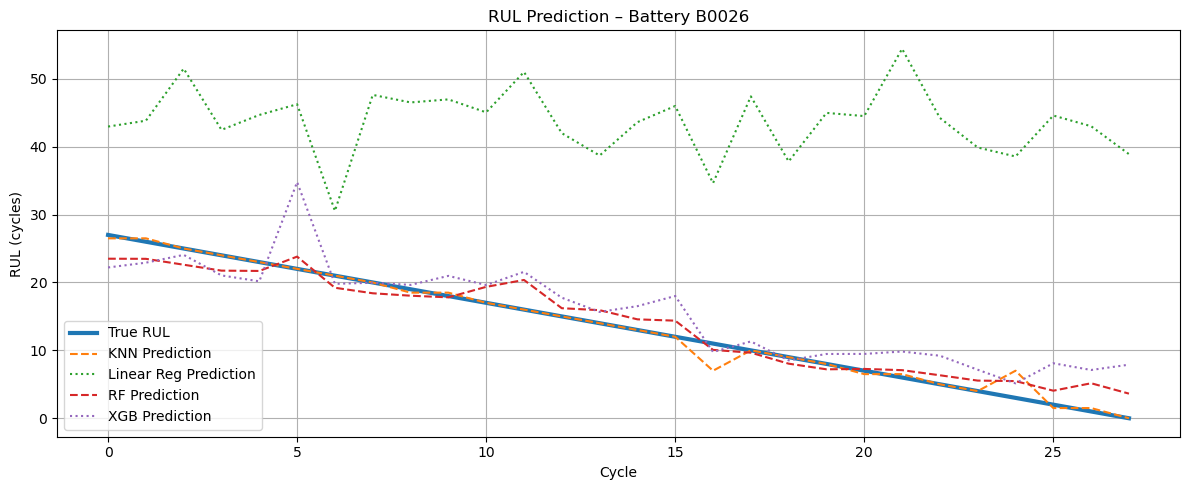

In [2486]:
for bat in bat_te:
    plot_rul_for_battery(dis_te, bat)